In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/pd/superstore.csv', encoding='latin1')

# Introduce missing values
df.loc[np.random.choice(df.index, 200), 'Sales'] = np.nan
df.loc[np.random.choice(df.index, 150), 'Region'] = np.nan
df.loc[np.random.choice(df.index, 100), 'Customer Name'] = np.nan

# Introduce duplicates
df = pd.concat([df, df.sample(50)], ignore_index=True)

# Introduce outliers
df.loc[np.random.choice(df.index, 10), 'Sales'] = 99999

# Save messy version
df.to_csv('messy_sales_data.csv', index=False)
print("Messy dataset created:", df.shape)
df.head()

Messy dataset created: (10044, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [26]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [27]:
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) *100
missing_df = pd.DataFrame({
    'Missing Values' : missing,
    'Percentage' : missing_percent
})

print(missing_df[missing_df["Missing Values"] > 0])

               Missing Values  Percentage
Customer Name             102    1.015532
Region                    151    1.503385
Sales                     201    2.001195


In [28]:
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

Total duplicate rows: 50


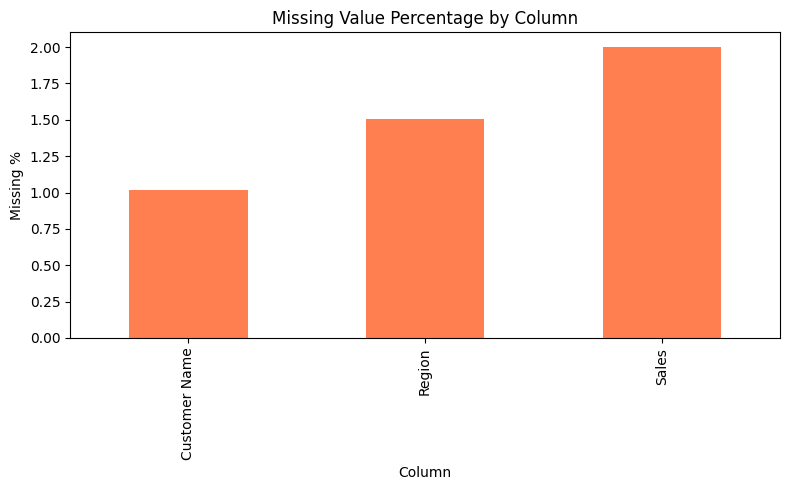

In [30]:
plt.figure(figsize=(8, 5))
missing_percent[missing_percent > 0].plot(kind='bar', color='coral')
plt.title('Missing Value Percentage by Column')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.tight_layout()
plt.savefig('missing_values.png')
plt.show()

In [31]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,10044.000000,10044.000000,9843.000000,10044.000000,10044.000000,10044.000000
mean,4995.036141,55218.303863,331.018585,3.789526,0.156087,28.527467
std,2887.069680,32064.084848,3239.406765,2.224103,0.206347,234.023252
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2494.750000,23223.000000,17.340000,2.000000,0.000000,1.730250
50%,4993.500000,56831.500000,54.792000,3.000000,0.200000,8.673300
75%,7497.250000,90008.000000,210.680000,5.000000,0.200000,29.372000
max,9994.000000,99301.000000,99999.000000,14.000000,0.800000,8399.976000
